# Projekt 2: Osäkerhets- och beslutsanalys
## VRSF20 2026

Melker Liljegren

## Konfiguration och bibliotek

Här laddas de bibliotek som används genomgående i analysen.

In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az

# För att slippa vissa loggar
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("pymc").setLevel(logging.ERROR)

## Inläsning av data del 1

### Olycksdata - Blekinge

Datasetet innehåller månatliga antal svårt skadade i trafikolyckor i Blekinge, uppdelat på kön, för perioden 2007–2024.

In [300]:
df_acc = pd.read_csv("blekinge.csv")
print(df_acc.shape)
df_acc.head(10)

(432, 4)


,year,month,sex,accidents
0,2007,January,female,0
1,2007,January,male,1
2,2008,January,female,2
3,2008,January,male,1
4,2009,January,female,1
5,2009,January,male,1
6,2010,January,female,0
7,2010,January,male,1
8,2011,January,female,1
9,2011,January,male,3


In [301]:
print(df_acc["year"].unique())
print(df_acc["sex"].unique())
print(df_acc["month"].unique())

[2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023 2024]
<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str


### Dos-responsdata

Datasetet innehåller responsmätningar från en djurstudie där försöksdjur exponerats för en kemikalie vid fyra dosnivåer (0, 25, 50, 100). Dessa data används för benchmark-dosmodellering i uppgift 5-6.

In [302]:
df_dose = pd.read_csv("data_ind_single.csv")
print(df_dose.shape)
df_dose.head()

(175, 2)


,dose,y
0,0,1.753358
1,0,1.628713
2,0,1.533369
3,0,1.085991
4,0,1.671930


In [303]:
print(df_dose["dose"].unique())
print(df_dose.groupby("dose")["y"].describe().round(3))

[  0  25  50 100]
      count   mean    std    min    25%    50%    75%    max
dose                                                        
0      50.0  1.466  0.310  0.843  1.182  1.525  1.664  2.036
25     40.0  1.922  0.329  1.221  1.683  1.890  2.109  2.867
50     45.0  2.802  0.266  2.336  2.612  2.780  3.004  3.374
100    40.0  3.875  0.345  3.229  3.596  3.867  4.118  4.563


## Del 1, Uppgift 1: Egen MCMC med Metropolis-Hastings

### Modell

Antalet svårt skadade per månad i Blekinge modelleras med en Poissonfördelning med log-länk:

$$Y_i \sim \text{Po}(\lambda_i), \quad \ln \lambda_i = \beta_0 + \beta_1 x_1$$

där $x_1 = 1$ om man och $0$ om kvinna. Parametern $\beta_0$ representerar den logaritmerade incidensfrekvensen för kvinnor, och $\beta_1$ fångar skillnaden mellan män och kvinnor på log-skalan.

### Bayesiansk ansats

Målet är att härleda posteriorfördelningen för $\beta_0$ och $\beta_1$ givet observerad data. Enligt Bayes sats gäller:

$$f(\beta_0, \beta_1 | y) \propto L(y | \beta_0, \beta_1) \cdot f(\beta_0) \cdot f(\beta_1)$$

Som prior används $\beta_0, \beta_1 \sim N(0, 1)$, vilket är svagt informativt. Likelihood-funktionen följer Poissonmodellen. Eftersom posteriorn inte kan beräknas analytiskt används MCMC-sampling.

### Metropolis-Hastings-algoritmen

Algoritmen fungerar genom att iterativt föreslå nya parametervärden och acceptera eller förkasta dem:

1. Starta med slumpmässiga värden dragna från priorn.
2. Föreslå nya värden genom att ta ett litet steg från nuvarande position: $\beta_{\text{ny}} = \beta_{\text{nuv}} + U(-w, w)$.
3. Beräkna log-posteriorvärdet för både nuvarande och föreslagna parametrar.
4. Om förslaget ger högre log-posterior accepteras det alltid. Om det ger lägre accepteras det med en sannolikhet som är proportionell mot kvoten mellan de två posteriorvärdena.
5. Upprepa tusentals gånger.

Steglängden $w = 0.1$ styr hur stora steg som föreslås. Ett för litet $w$ ger långsam utforskning, ett för stort ger hög andel förkastade förslag. Log-posteriorn beräknas som summan av Poisson log-likelihooden och log-priorn, där konstanta termer utelämnas eftersom de försvinner vid jämförelsen.

In [304]:
# Förbered data
df_acc["x1"] = (df_acc["sex"] == "male").astype(int)
y = df_acc["accidents"].values
x1 = df_acc["x1"].values

# Log-posterior: hur bra är en gissning på b0, b1?
def log_posterior(b0, b1):
    log_lam = b0 + b1 * x1
    ll = np.sum(y * log_lam - np.exp(log_lam))   # Poisson log-likelihood
    lp = -0.5 * (b0**2 + b1**2)                   # N(0,1) prior
    return ll + lp

# Metropolis-Hastings: föreslå, jämför, acceptera/förkasta
def run_mh(n_iter=5000, w=0.1, seed=None):
    rng = np.random.default_rng(seed)
    b0, b1 = rng.normal(0, 1), rng.normal(0, 1)
    cur_lp = log_posterior(b0, b1)
    samples = np.zeros((n_iter, 2))

    for i in range(n_iter):
        b0_new = b0 + rng.uniform(-w, w)
        b1_new = b1 + rng.uniform(-w, w)
        new_lp = log_posterior(b0_new, b1_new)

        if np.log(rng.uniform()) < new_lp - cur_lp:
            b0, b1, cur_lp = b0_new, b1_new, new_lp

        samples[i] = [b0, b1]
    return samples

### Konvergensdiagnostik

Tre kedjor körs med olika startvärden för att bedöma konvergens. Om kedjorna oberoende av startpunkt konvergerar till samma område i parameterrummet tyder det på att samplern har hittat posteriorfördelningen. Kedjor som inte blandas kan tyda på för få iterationer eller olämplig steglängd.

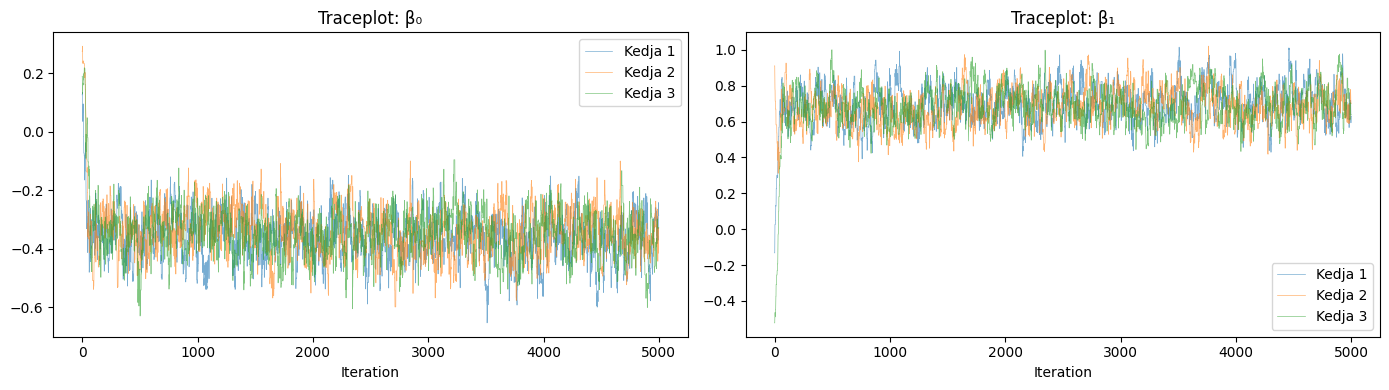

In [305]:
chains = [run_mh(n_iter=5000, seed=c) for c in range(3)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for j, name in enumerate(["β₀", "β₁"]):
    for c, chain in enumerate(chains):
        axes[j].plot(chain[:, j], alpha=0.6, linewidth=0.5, label=f"Kedja {c+1}")
    axes[j].set_title(f"Traceplot: {name}")
    axes[j].set_xlabel("Iteration")
    axes[j].legend()
plt.tight_layout()
plt.show()

### Posterior-sammanfattning

De första 1000 iterationerna kasseras som burn-in, eftersom de tidiga stegen speglar startgissningen snarare än den faktiska posteriorfördelningen. De resterande stickproven från alla tre kedjor slås samman och sammanfattas med medelvärde, standardavvikelse och 90%-intervall. Resultaten bör ligga nära MLE-skattningarna från övning 4 ($\beta_0 \approx -0.35$, $\beta_1 \approx 0.69$), vilket verifierar att den egna samplern fungerar korrekt.

In [306]:
burn_in = 1000
posterior = np.vstack([c[burn_in:] for c in chains])

for j, name in enumerate(["β₀", "β₁"]):
    s = posterior[:, j]
    print(f"{name}: medel={s.mean():.4f}, sd={s.std():.4f}, "
          f"90% KI=({np.percentile(s, 5):.4f}, {np.percentile(s, 95):.4f})")

β₀: medel=-0.3557, sd=0.0781, 90% KI=(-0.4874, -0.2302)
β₁: medel=0.6971, sd=0.0980, 90% KI=(0.5405, 0.8650)


## Del 1, Uppgift 2: Bayesiansk GLM med Bambi

Samma modell anpassas nu med bambi, som använder NUTS-samplern. Till skillnad från vår Metropolis-Hastings anpassar NUTS steglängd och riktning automatiskt, vilket ger snabbare konvergens utan manuell justering. Vi kör 4 kedjor med 2000 dragningar efter 1000 tune-iterationer. Genom att jämföra resultaten verifieras att den egna samplern i uppgift 1 fungerar korrekt.

In [307]:
model1 = bmb.Model("accidents ~ x1", data=df_acc, family="poisson", link="log")
trace1 = model1.fit(draws=2000, tune=1000, chains=4, random_seed=42)
az.summary(trace1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.355,0.082,-0.510,-0.207,0.001,0.001,6520.0,5155.0,1.0
x1,0.695,0.101,0.502,0.881,0.001,0.001,6542.0,4858.0,1.0


### Konvergensdiagnostik

Trace plots visar att kedjorna blandas väl, vilket bekräftar konvergens. Jämfört med den egna samplern i uppgift 1 konvergerar NUTS snabbare och ger jämnare kedjor, vilket illustrerar fördelen med mer avancerade MCMC-metoder.

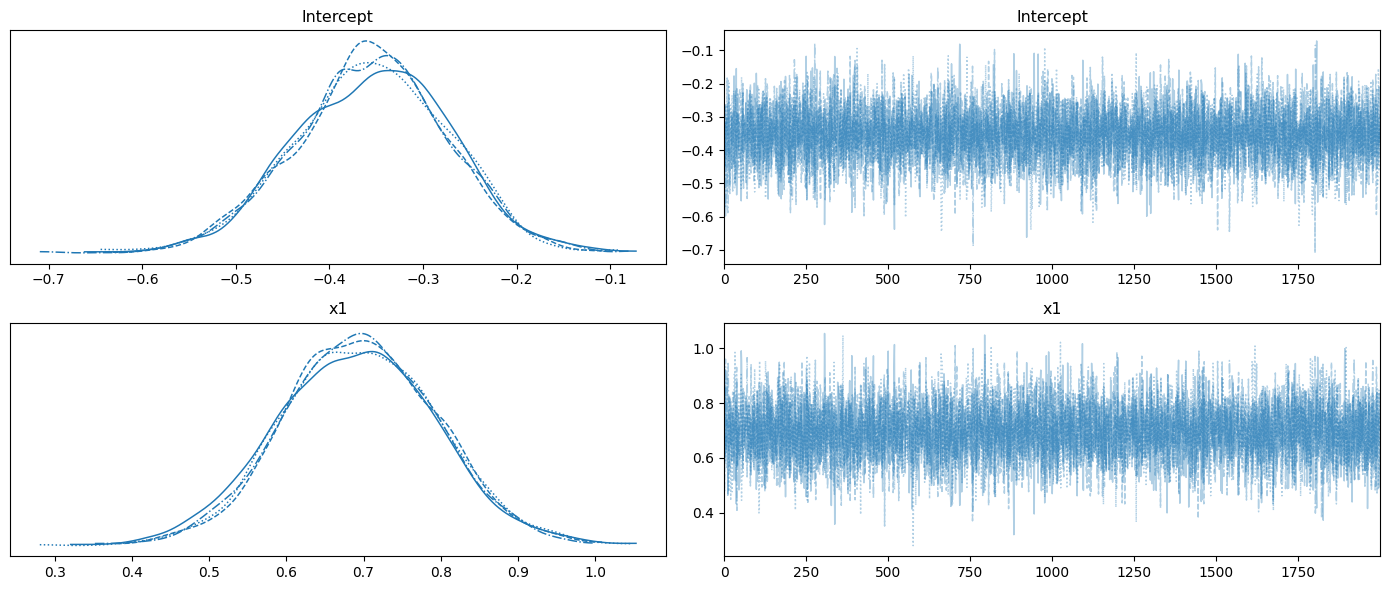

In [308]:
az.plot_trace(trace1, figsize=(14, 6))
plt.tight_layout()
plt.show()

### Jämförelse med egen MCMC

Bambi rapporterar Intercept ($\beta_0$) och x1 ($\beta_1$). Om medelvärden och standardavvikelser överensstämmer med den egna samplern bekräftar det att Metropolis-Hastings-implementationen i uppgift 1 är korrekt. Eventuella små skillnader förklaras av att MCMC-sampling alltid har viss slumpmässig variation.

In [309]:
print("Bambi:")
print(az.summary(trace1)[["mean", "sd", "hdi_3%", "hdi_97%"]])

print("\nEgen MCMC:")
for j, name in enumerate(["β₀ (Intercept)", "β₁ (x1)"]):
    s = posterior[:, j]
    print(f"  {name}: medel={s.mean():.4f}, sd={s.std():.4f}")

Bambi:
            mean     sd  hdi_3%  hdi_97%
Intercept -0.355  0.082  -0.510   -0.207
x1         0.695  0.101   0.502    0.881

Egen MCMC:
  β₀ (Intercept): medel=-0.3557, sd=0.0781
  β₁ (x1): medel=0.6971, sd=0.0980


## Del 1, Uppgift 3: Modell 7 och 9 i Bambi

För att besvara riskfrågan behöver vi modeller som fångar de viktigaste förklarande variablerna. Från övning 4 identifierades modell 7 och 9 som de bästa kandidaterna. Båda är Poissonmodeller med log-länk:

**Modell 7:** $\ln \lambda = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_4 x_4$

**Modell 9:** $\ln \lambda = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \beta_4 x_4$

där $x_1$ = kön (man), $x_2$ = sommar (juni/juli), $x_3$ = årstrend (år − 2015), och $x_4$ = stegförändring (1 om år ≥ 2015). Modellerna anpassas i ett Bayesianskt ramverk för att kvantifiera parameterosäkerhet, och ELPD-vikter beräknas för modelmedelvägning.

### Skapa kovariater och anpassa modellerna

Modell 7 och 9 delar kovariaterna $x_1$, $x_2$ och $x_4$. Den enda skillnaden är att modell 9 även inkluderar $x_3$ (linjär årstrend). Båda anpassas med log-likelihood aktiverat för att möjliggöra ELPD-beräkning.

In [310]:
df_acc["x2"] = df_acc["month"].isin(["June", "July"]).astype(int)
df_acc["x3"] = df_acc["year"] - 2015
df_acc["x4"] = (df_acc["year"] >= 2015).astype(int)

model7 = bmb.Model("accidents ~ x1 + x2 + x4", data=df_acc, family="poisson", link="log")
trace7 = model7.fit(draws=2000, tune=1000, chains=4, random_seed=42, idata_kwargs={"log_likelihood": True})

model9 = bmb.Model("accidents ~ x1 + x2 + x3 + x4", data=df_acc, family="poisson", link="log")
trace9 = model9.fit(draws=2000, tune=1000, chains=4, random_seed=42, idata_kwargs={"log_likelihood": True})

### Posterior-sammanfattning

Skattningarna jämförs med MLE-värdena från övning 4 för att verifiera att de Bayesianska modellerna ger rimliga resultat. En viktig observation är huruvida $x_3$ (årstrend) i modell 9 är signifikant, om dess kredibilitetsintervall inkluderar noll tyder det på att stegförändringen $x_4$ redan fångar tidstrenden.

In [311]:
print("Modell 7:")
print(az.summary(trace7)[["mean", "sd", "hdi_3%", "hdi_97%"]])
print("\nModell 9:")
print(az.summary(trace9)[["mean", "sd", "hdi_3%", "hdi_97%"]])

Modell 7:
            mean     sd  hdi_3%  hdi_97%
Intercept -0.087  0.092  -0.267    0.082
x1         0.694  0.098   0.510    0.881
x2         0.399  0.112   0.189    0.604
x4        -0.753  0.098  -0.930   -0.565

Modell 9:
            mean     sd  hdi_3%  hdi_97%
Intercept -0.033  0.123  -0.265    0.193
x1         0.695  0.100   0.508    0.884
x2         0.397  0.111   0.182    0.603
x3         0.012  0.019  -0.024    0.046
x4        -0.864  0.193  -1.220   -0.496


### Modellvikter via ELPD

Vikterna baseras på ELPD (Expected Log Pointwise Predictive Density), ett mått på modellernas prediktiva förmåga. Högre ELPD innebär bättre prediktioner. Vikterna beräknas som:

$$\Delta ELPD_j = \max_j ELPD - ELPD_j, \quad w_j = \frac{e^{-\Delta ELPD_j}}{\sum_j e^{-\Delta ELPD_j}}$$

In [312]:
elpd7 = az.loo(trace7).elpd_loo
elpd9 = az.loo(trace9).elpd_loo

delta7 = max(elpd7, elpd9) - elpd7
delta9 = max(elpd7, elpd9) - elpd9

w7 = np.exp(-delta7) / (np.exp(-delta7) + np.exp(-delta9))
w9 = np.exp(-delta9) / (np.exp(-delta7) + np.exp(-delta9))

print(f"ELPD Modell 7: {elpd7:.2f}")
print(f"ELPD Modell 9: {elpd9:.2f}")
print(f"\nVikter: w7 = {w7:.4f}, w9 = {w9:.4f}")

ELPD Modell 7: -520.88
ELPD Modell 9: -521.55

Vikter: w7 = 0.6613, w9 = 0.3387


## Del 1, Uppgift 4: Modelmedelvägning och riskbedömning

Riskfrågan från övning 4 besvaras nu med hänsyn till osäkerhet i både parametrar och modellstruktur. Prediktorvärden för juni 2026 sätts till $x_1 = 1$ (man), $x_2 = 1$ (juni/juli), $x_3 = 11$, $x_4 = 1$. Notera att modellerna inte skiljer mellan juni och juli, $x_2$ är en gemensam dummyvariabel för båda månaderna.

För varje posterior-dragning beräknas $\lambda$ och sannolikheten $P(Y > 2) = 1 - P(Y \leq 2)$ från Poissonfördelningen. Den modelmedelvägda sannolikheten ges av:

$$p_{MA} = w_7 \cdot p_7 + w_9 \cdot p_9$$

In [313]:
from scipy.stats import poisson

# Modell 7: ln(lambda) = b0 + b1*1 + b2*1 + b4*1
post7 = trace7.posterior.stack(sample=("chain", "draw"))
lam7 = np.exp(post7["Intercept"].values + post7["x1"].values + post7["x2"].values + post7["x4"].values)
p7 = 1 - poisson.cdf(2, lam7)

# Modell 9: ln(lambda) = b0 + b1*1 + b2*1 + b3*11 + b4*1
post9 = trace9.posterior.stack(sample=("chain", "draw"))
lam9 = np.exp(post9["Intercept"].values + post9["x1"].values + post9["x2"].values + post9["x3"].values * 11 + post9["x4"].values)
p9 = 1 - poisson.cdf(2, lam9)

# Modelmedelvägd sannolikhet
p_MA = w7 * p7.mean() + w9 * p9.mean()

print(f"P(Y > 2) Modell 7: {p7.mean():.4f}")
print(f"P(Y > 2) Modell 9: {p9.mean():.4f}")
print(f"\nModelmedelvägd P(Y > 2): {p_MA:.4f}")

P(Y > 2) Modell 7: 0.1439
P(Y > 2) Modell 9: 0.1717

Modelmedelvägd P(Y > 2): 0.1533


## Del 1, Uppgift 5: Benchmark-dosmodellering

Vi övergår nu till dos-responsdata från en djurstudie. Syftet är att härleda osäkerhetsfördelningen för benchmark-dosen (BMD), den lägsta dosen som orsakar en 5% ökning av responsen relativt bakgrunden:

$$BMR = (1 + p) \cdot \mu(\text{dose} = 0), \quad p = 0.05$$

Två modeller anpassas:

**Linjär:** $Y|\text{dose} \sim N(\beta_0 + \beta_1 \cdot \text{dose},\; \sigma)$

**Kubisk:** $Y|\text{dose} \sim N(\beta_0 + \beta_1 d + \beta_2 d^2 + \beta_3 d^3,\; \sigma)$

Den kubiska modellen använder centrerade och skalade dosvärden för numerisk stabilitet. BMD härleds för varje posterior-dragning, analytiskt för den linjära modellen och numeriskt för den kubiska. Modellvikter beräknas med samma ELPD-metod som i uppgift 3.

### Utforska dos-responsdata

Boxplotten nedan ger en överblick av hur responsen fördelar sig vid varje dosnivå. En tydlig ökning med dosen tyder på ett dos-responssamband.

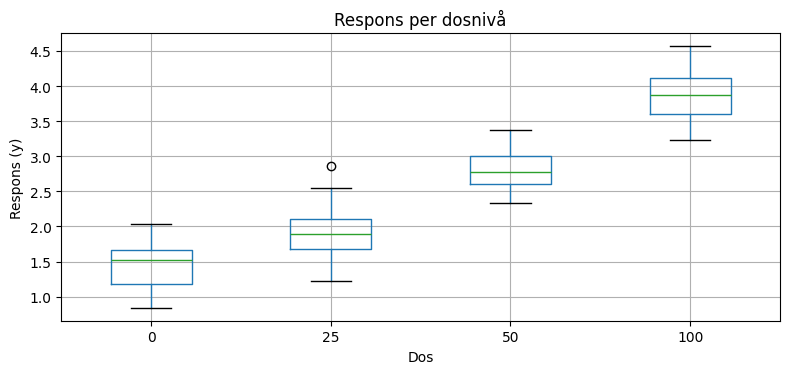

In [314]:
fig, ax = plt.subplots(figsize=(8, 4))
df_dose.boxplot(column="y", by="dose", ax=ax)
ax.set_xlabel("Dos")
ax.set_ylabel("Respons (y)")
ax.set_title("Respons per dosnivå")
plt.suptitle("")
plt.tight_layout()
plt.show()

### Anpassa linjär och kubisk modell

Den linjära modellen antar ett konstant samband mellan dos och respons. Den kubiska modellen tillåter ett mer flexibelt, icke-linjärt samband. Dosvärden centreras och skalas före polynomregressen för att undvika numeriska problem vid MCMC-sampling, utan detta skiljer sig koefficienterna med flera storleksordningar, vilket försvårar samplern.

In [315]:
# Polynomfeatures för kubisk modell
dose_mean = df_dose["dose"].mean()
dose_sd = df_dose["dose"].std()
df_dose["d_z"] = (df_dose["dose"] - dose_mean) / dose_sd
df_dose["d_z2"] = df_dose["d_z"] ** 2
df_dose["d_z3"] = df_dose["d_z"] ** 3

model_lin = bmb.Model("y ~ dose", data=df_dose)
trace_lin = model_lin.fit(draws=2000, tune=1000, chains=4, random_seed=42, idata_kwargs={"log_likelihood": True})

model_cub = bmb.Model("y ~ d_z + d_z2 + d_z3", data=df_dose)
trace_cub = model_cub.fit(draws=2000, tune=1000, chains=4, random_seed=42, idata_kwargs={"log_likelihood": True})

print("Linjär modell:")
print(az.summary(trace_lin)[["mean", "sd", "hdi_3%", "hdi_97%"]])
print("\nKubisk modell:")
print(az.summary(trace_cub)[["mean", "sd", "hdi_3%", "hdi_97%"]])

Linjär modell:
            mean     sd  hdi_3%  hdi_97%
sigma      0.327  0.018   0.293    0.360
Intercept  1.441  0.038   1.370    1.511
dose       0.025  0.001   0.023    0.026

Kubisk modell:
            mean     sd  hdi_3%  hdi_97%
sigma      0.314  0.017   0.282    0.346
Intercept  2.482  0.037   2.412    2.552
d_z        1.365  0.119   1.154    1.600
d_z2       0.113  0.046   0.023    0.195
d_z3      -0.264  0.069  -0.390   -0.131


### ELPD-vikter

ELPD beräknas som i uppgift 3. En stor viktskillnad tyder på att en modell fångar dos-responsförhållandet väsentligt bättre.

In [316]:
elpd_lin = az.loo(trace_lin).elpd_loo
elpd_cub = az.loo(trace_cub).elpd_loo

delta_lin = max(elpd_lin, elpd_cub) - elpd_lin
delta_cub = max(elpd_lin, elpd_cub) - elpd_cub

w_lin = np.exp(-delta_lin) / (np.exp(-delta_lin) + np.exp(-delta_cub))
w_cub = np.exp(-delta_cub) / (np.exp(-delta_lin) + np.exp(-delta_cub))

print(f"ELPD linjär: {elpd_lin:.2f}, kubisk: {elpd_cub:.2f}")
print(f"Vikter: w_lin = {w_lin:.4f}, w_cub = {w_cub:.4f}")

ELPD linjär: -53.37, kubisk: -47.69
Vikter: w_lin = 0.0034, w_cub = 0.9966


### BMD-fördelning per modell

För den linjära modellen kan BMD härledas algebraiskt: $\mu(\text{dose}) = BMR$ ger $BMD = p \cdot \beta_0 / \beta_1$. För den kubiska modellen saknas en sluten lösning, och BMD beräknas numeriskt för varje posterior-dragning. Endast dragningar där dos-responskurvan faktiskt korsar BMR-nivån ger en lösbar BMD, dragningar med för platta kurvor exkluderas, vilket ger en konservativ skattning i linje med försiktighetsprincipen.

In [317]:
from scipy.optimize import brentq

p = 0.05
post_lin = trace_lin.posterior.stack(sample=("chain", "draw"))
post_cub = trace_cub.posterior.stack(sample=("chain", "draw"))

# Linjär: BMD = p * b0 / b1
b0_lin = post_lin["Intercept"].values
b1_lin = post_lin["dose"].values
bmd_lin = p * b0_lin / b1_lin
bmd_lin = bmd_lin[bmd_lin > 0]  # Behåll fysiskt rimliga värden

# Kubisk: lös numeriskt
b0_c = post_cub["Intercept"].values
b1_c = post_cub["d_z"].values
b2_c = post_cub["d_z2"].values
b3_c = post_cub["d_z3"].values

def mu_cub(dose, b0, b1, b2, b3):
    dz = (dose - dose_mean) / dose_sd
    return b0 + b1*dz + b2*dz**2 + b3*dz**3

bmd_cub = []
for i in range(len(b0_c)):
    mu0 = mu_cub(0, b0_c[i], b1_c[i], b2_c[i], b3_c[i])
    bmr = (1 + p) * mu0
    try:
        f = lambda d: mu_cub(d, b0_c[i], b1_c[i], b2_c[i], b3_c[i]) - bmr
        if f(0.01) * f(150) < 0:
            bmd_cub.append(brentq(f, 0.01, 150))
    except:
        pass

bmd_cub = np.array(bmd_cub)

### Modelmedelvägd BMD

BMD-stickproven blandas proportionellt mot ELPD-vikterna. Den resulterande fördelningen representerar osäkerheten i benchmark-dosen givet osäkerhet i både parametrar och modellstruktur. Fördelningen sammanfattas med median och 90% kredibilitetsintervall.

In [318]:
# Blanda stickprov proportionellt mot vikterna
n = min(len(bmd_lin), len(bmd_cub))
bmd_MA = w_lin * bmd_lin[:n] + w_cub * bmd_cub[:n]

print(f"BMD linjär:  median={np.median(bmd_lin):.2f}, 90% KI=({np.percentile(bmd_lin, 5):.2f}, {np.percentile(bmd_lin, 95):.2f})")
print(f"BMD kubisk:  median={np.median(bmd_cub):.2f}, 90% KI=({np.percentile(bmd_cub, 5):.2f}, {np.percentile(bmd_cub, 95):.2f})")
print(f"BMD MA:      median={np.median(bmd_MA):.2f}, 90% KI=({np.percentile(bmd_MA, 5):.2f}, {np.percentile(bmd_MA, 95):.2f})")

BMD linjär:  median=2.92, 90% KI=(2.69, 3.17)
BMD kubisk:  median=5.55, 90% KI=(3.72, 8.15)
BMD MA:      median=5.54, 90% KI=(3.72, 8.13)


## Del 1, Uppgift 6: Bayesiansk beslutsanalys

Beslutsproblemet är att välja ett HBGV (Health Based Guidance Value), den högsta acceptabla dosen, givet osäkerheten i BMD. Beslutsfattaren anser att ett för högt värde (otillräckligt skyddande) är allvarligare än ett för lågt (överprotektivt). Detta fångas av LINEX-förlustfunktionen med $\alpha = 0.3$:

$$L(\delta, \psi) = e^{\alpha(\delta - \psi)} - \alpha(\delta - \psi) - 1$$

Det Bayes-optimala beslutet minimerar den förväntade förlusten och ges analytiskt av:

$$\delta^* = -\frac{1}{\alpha} \ln E[e^{-\alpha \cdot \psi}]$$

Eftersom LINEX straffar överskattning exponentiellt förväntas det optimala HBGV:t ligga under medianen av BMD-fördelningen.

In [319]:
alpha = 0.3

# Analytisk lösning
hbgv = -(1/alpha) * np.log(np.mean(np.exp(-alpha * bmd_MA)))

print(f"Bayes-optimalt HBGV (p=5%, α=0.3): {hbgv:.2f}")

Bayes-optimalt HBGV (p=5%, α=0.3): 5.45


### Visualisering

LINEX-förlustfunktionen och BMD-fördelningen med det valda HBGV illustreras nedan. Det optimala värdet ligger till vänster om medianen, vilket speglar beslutsfattarens asymmetriska preferens.

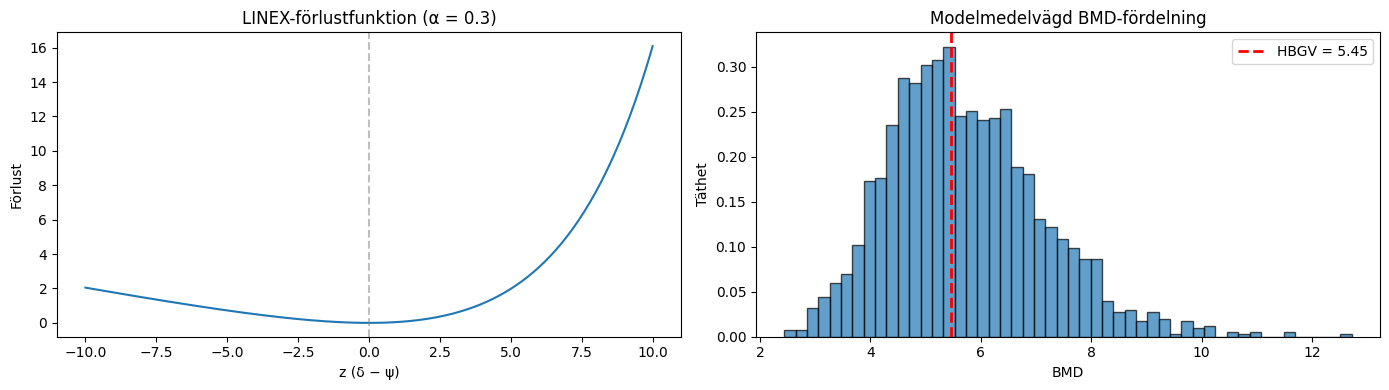

In [320]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LINEX-förlustfunktionen
z = np.linspace(-10, 10, 200)
loss = np.exp(alpha * z) - alpha * z - 1
axes[0].plot(z, loss)
axes[0].set_xlabel("z (δ − ψ)")
axes[0].set_ylabel("Förlust")
axes[0].set_title("LINEX-förlustfunktion (α = 0.3)")
axes[0].axvline(0, color="grey", linestyle="--", alpha=0.5)

# BMD-fördelning med HBGV markerat
axes[1].hist(bmd_MA, bins=50, density=True, alpha=0.7, edgecolor="black")
axes[1].axvline(hbgv, color="red", linestyle="--", linewidth=2, label=f"HBGV = {hbgv:.2f}")
axes[1].set_xlabel("BMD")
axes[1].set_ylabel("Täthet")
axes[1].set_title("Modelmedelvägd BMD-fördelning")
axes[1].legend()

plt.tight_layout()
plt.show()

## Del 2, uppgift 1: Biasjusterad benchmark-dosanalys

Studentspecifik dos-responsdata innehåller observationer från studie A (46 st) och studie B (30 st). Experter bedömer att studie B systematiskt mäter för högt, men inte med hur mycket. Vi hanterar detta genom att lägga till en extra term ($\beta_s$) i modellen som fångar skillnaden mellan studierna. När vi sedan beräknar BMD utgår vi enbart från studie A:s nivå (studyB = 0) så att överskattningen inte påverkar gränsvärdet.

In [321]:
df_student = pd.read_csv("projekt2_me7337li.csv")
print(df_student.shape)
print(df_student.groupby("study")["y"].describe().round(3))

(76, 3)
        count   mean    std    min    25%    50%    75%    max
study                                                         
studyA   46.0  2.489  0.995  0.843  1.673  2.403  3.337  4.563
studyB   30.0  3.245  0.841  2.127  2.525  2.991  3.801  5.110


### Biasjusterade dos-responsmodeller

Två modeller anpassas med en extra term för studieeffekten:

**Linjär:** $\mu(\text{dose}) = \beta_0 + \beta_1 \cdot \text{dose} + \beta_s \cdot \text{studyB}$

**Kubisk:** $\mu(\text{dose}) = \beta_0 + \beta_1 d + \beta_2 d^2 + \beta_3 d^3 + \beta_s \cdot \text{studyB}$

En positiv $\beta_s$ bekräftar experternas bedömning att studie B systematiskt överskattar responsen. Studie B ger i snitt ca 58% högre respons vid bakgrundsdosen.

In [322]:
df_student["studyB"] = (df_student["study"] == "studyB").astype(int)

dose_mean_s = df_student["dose"].mean()
dose_sd_s = df_student["dose"].std()
df_student["d_z"] = (df_student["dose"] - dose_mean_s) / dose_sd_s
df_student["d_z2"] = df_student["d_z"] ** 2
df_student["d_z3"] = df_student["d_z"] ** 3

model_lin_s = bmb.Model("y ~ dose + studyB", data=df_student)
trace_lin_s = model_lin_s.fit(draws=2000, tune=1000, chains=4, random_seed=42, idata_kwargs={"log_likelihood": True})

model_cub_s = bmb.Model("y ~ d_z + d_z2 + d_z3 + studyB", data=df_student)
trace_cub_s = model_cub_s.fit(draws=2000, tune=1000, chains=4, random_seed=42, idata_kwargs={"log_likelihood": True})

print("Linjär modell:")
print(az.summary(trace_lin_s)[["mean", "sd", "hdi_3%", "hdi_97%"]])
print("\nKubisk modell:")
print(az.summary(trace_cub_s)[["mean", "sd", "hdi_3%", "hdi_97%"]])

Linjär modell:
            mean     sd  hdi_3%  hdi_97%
sigma      0.338  0.028   0.286    0.391
Intercept  1.491  0.067   1.370    1.620
dose       0.024  0.001   0.022    0.027
studyB     0.855  0.080   0.707    1.004

Kubisk modell:
            mean     sd  hdi_3%  hdi_97%
sigma      0.326  0.028   0.277    0.378
Intercept  2.441  0.070   2.320    2.581
d_z        1.306  0.162   1.009    1.610
d_z2       0.153  0.078  -0.002    0.295
d_z3      -0.246  0.091  -0.414   -0.076
studyB     0.864  0.078   0.716    1.008


### ELPD-vikter, BMD och HBGV

Vikterna beräknas som i del 1. Vid BMD-härledningen sätts studyB = 0 så att gränsvärdet baseras på studie A:s nivå. HBGV väljs via LINEX ($\alpha = 0.3$).

In [323]:
elpd_lin_s = az.loo(trace_lin_s).elpd_loo
elpd_cub_s = az.loo(trace_cub_s).elpd_loo

delta_lin_s = max(elpd_lin_s, elpd_cub_s) - elpd_lin_s
delta_cub_s = max(elpd_lin_s, elpd_cub_s) - elpd_cub_s

w_lin_s = np.exp(-delta_lin_s) / (np.exp(-delta_lin_s) + np.exp(-delta_cub_s))
w_cub_s = np.exp(-delta_cub_s) / (np.exp(-delta_lin_s) + np.exp(-delta_cub_s))

print(f"ELPD linjär: {elpd_lin_s:.2f}, kubisk: {elpd_cub_s:.2f}")
print(f"Vikter: w_lin = {w_lin_s:.4f}, w_cub = {w_cub_s:.4f}")

# BMD linjär (studyB = 0)
p = 0.05
post_lin_s = trace_lin_s.posterior.stack(sample=("chain", "draw"))
b0_lin_s = post_lin_s["Intercept"].values
b1_lin_s = post_lin_s["dose"].values
bmd_lin_s = p * b0_lin_s / b1_lin_s
bmd_lin_s = bmd_lin_s[bmd_lin_s > 0]

# BMD kubisk (studyB = 0)
post_cub_s = trace_cub_s.posterior.stack(sample=("chain", "draw"))
b0_cs = post_cub_s["Intercept"].values
b1_cs = post_cub_s["d_z"].values
b2_cs = post_cub_s["d_z2"].values
b3_cs = post_cub_s["d_z3"].values

def mu_cub_s(dose, b0, b1, b2, b3):
    dz = (dose - dose_mean_s) / dose_sd_s
    return b0 + b1*dz + b2*dz**2 + b3*dz**3

bmd_cub_s = []
for i in range(len(b0_cs)):
    mu0 = mu_cub_s(0, b0_cs[i], b1_cs[i], b2_cs[i], b3_cs[i])
    bmr = (1 + p) * mu0
    try:
        f = lambda d: mu_cub_s(d, b0_cs[i], b1_cs[i], b2_cs[i], b3_cs[i]) - bmr
        if f(0.01) * f(150) < 0:
            bmd_cub_s.append(brentq(f, 0.01, 150))
    except:
        pass
bmd_cub_s = np.array(bmd_cub_s)

# Blanda stickprov proportionellt mot vikterna
n_s = min(len(bmd_lin_s), len(bmd_cub_s))
bmd_MA_s = w_lin_s * bmd_lin_s[:n_s] + w_cub_s * bmd_cub_s[:n_s]

# HBGV
alpha = 0.3
hbgv_s = -(1/alpha) * np.log(np.mean(np.exp(-alpha * bmd_MA_s)))

print(f"\nBMD MA: median={np.median(bmd_MA_s):.2f}, 90% KI=({np.percentile(bmd_MA_s, 5):.2f}, {np.percentile(bmd_MA_s, 95):.2f})")
print(f"Bayes-optimalt HBGV: {hbgv_s:.2f}")

ELPD linjär: -26.53, kubisk: -24.75
Vikter: w_lin = 0.1443, w_cub = 0.8557

BMD MA: median=4.99, 90% KI=(3.05, 8.62)
Bayes-optimalt HBGV: 4.88


### Visualisering

HBGV:t baseras nu på studentspecifik data med biasjustering. Jämfört med del 1 förväntas osäkerheten vara större på grund av färre observationer (76 vs 175), men biasjusteringen säkerställer att gränsvärdet inte snedvrids av studie B:s överskattning.

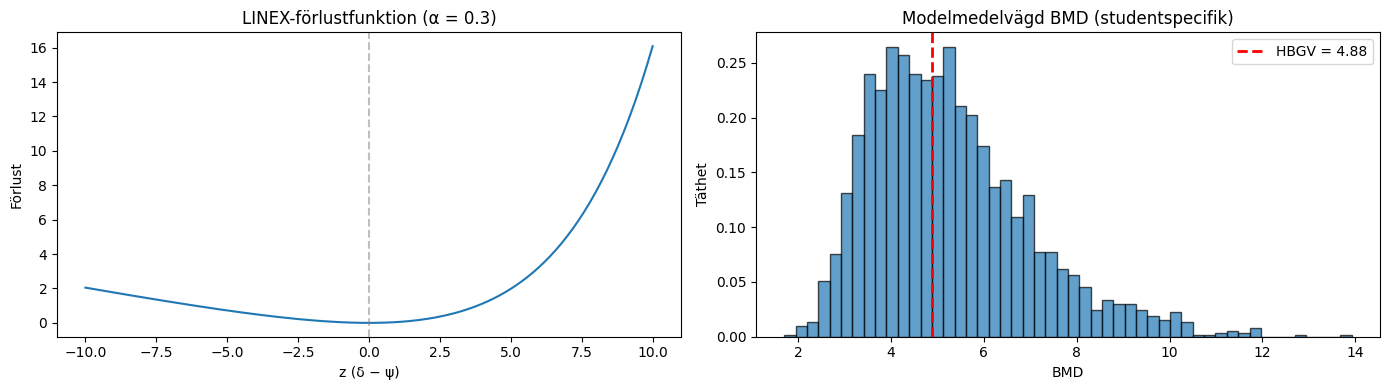

In [324]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

z = np.linspace(-10, 10, 200)
axes[0].plot(z, np.exp(alpha * z) - alpha * z - 1)
axes[0].set_xlabel("z (δ − ψ)")
axes[0].set_ylabel("Förlust")
axes[0].set_title("LINEX-förlustfunktion (α = 0.3)")
axes[0].axvline(0, color="grey", linestyle="--", alpha=0.5)

axes[1].hist(bmd_MA_s, bins=50, density=True, alpha=0.7, edgecolor="black")
axes[1].axvline(hbgv_s, color="red", linestyle="--", linewidth=2, label=f"HBGV = {hbgv_s:.2f}")
axes[1].set_xlabel("BMD")
axes[1].set_ylabel("Täthet")
axes[1].set_title("Modelmedelvägd BMD (studentspecifik)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Rekommendation till beslutsfattaren

Baserat på dos-responsdata från två oberoende djurstudier och Bayesiansk modellering rekommenderas ett hälsobaserat gränsvärde (HBGV) på 4.88 dosenhet. Gränsvärdet anger den högsta dos som bedöms acceptabel givet tillgänglig information och osäkerhet.

Analysen bygger på att en linjär och en kubisk dos-responsmodell anpassades till data från båda studierna. Studie B identifierades av vetenskapliga experter som systematiskt överskattande, vilket hanterades genom att inkludera en biasjusteringsterm i modellerna. Denna term gör det möjligt att utnyttja informationen i studie B utan att den systematiska överskattningen snedvrider skattningen av dos-responsförhållandet. Benchmark-dosen (BMD), den lägsta dos som ger en 5-procentig ökning av responsen relativt bakgrunden, härleddes från posteriorfördelningarna och modellmedelvägdes baserat på modellernas prediktiva förmåga.

Det slutliga gränsvärdet valdes genom att minimera den förväntade förlusten under en asymmetrisk förlustfunktion (LINEX) med $\alpha = 0.3$, som straffar ett för högt gränsvärde exponentiellt och ett för lågt linjärt. Det valda HBGV:t ligger därför under medianen av BMD-fördelningen, vilket speglar att prioriteringen ligger på att skydda snarare än att vara exakt.

Osäkerheten i resultatet härstammar från tre källor: begränsad datamängd, osäkerhet i modellstruktur (linjär vs kubisk), samt den okända storleken på biasen i studie B. Samtliga osäkerhetskällor propageras genom analysen via Bayesiansk inferens och modelmedelvägning.

## Del 2, uppgift 2: Robust beslutsanalys - kylsystem vid kärnkraftverk

Ett företag ska välja mellan (A) passiv kylning och (B) soldriven kylning. Beslutsfattaren föredrar det alternativ som ger lägst sannolikhet för minst en incident under ett år: $P(Y > 0) = 1 - e^{-\lambda(T, d)}$.

Analysen kombinerar tre osäkerhetskällor: parameterosäkerhet i incidensmodellen (probabilistisk), expertbedömningar av relativ prestanda mellan systemen (probabilistisk), samt klimatscenarier (icke-probabilistisk). Den robusta ansatsen innebär att vi utvärderar beslutet under varje klimatscenario separat, snarare än att vikta dem till ett enda förväntningsvärde.

### Steg 1: Kalibrering av incidensmodell för passiv kylning

Data från 20 kärnkraftverk med passiv kylning används för att skatta sambandet mellan medeltemperatur och incidensfrekvens. Modellen är en Poisson-GLM med log-länk och observationstiden som offset (eftersom kärnkraftverken observerats under olika lång tid):

$$Y_i \sim \text{Po}(\lambda_i \cdot t_i), \quad \ln \lambda_i(T, d_A) + \ln t_i = \beta_{0,A} + \beta_{1,A} T$$

En positiv $\beta_{1,A}$ innebär att incidensfrekvensen ökar med temperaturen.

In [325]:
df_npp = pd.read_csv("npp_data.csv")
df_npp["log_t"] = np.log(df_npp["t"])

model_npp = bmb.Model(
    "y ~ tav + offset(log_t)",
    data=df_npp,
    family="poisson",
    link="log"
)
trace_npp = model_npp.fit(draws=2000, tune=1000, chains=4, random_seed=42)

print(az.summary(trace_npp)[["mean", "sd", "hdi_3%", "hdi_97%"]])

            mean     sd  hdi_3%  hdi_97%
Intercept -0.193  0.175  -0.538    0.120
tav        0.079  0.014   0.052    0.105


### Steg 2: Härleda parametrar för soldriven kylning via expertbedömningar

Experterna har bedömt kvoterna $\lambda(4,B)/\lambda(4,A)$ och $\lambda(10,B)/\lambda(10,A)$. Eftersom $\ln\lambda(T,d) = \beta_0 + \beta_1 T$ kan vi härleda $\beta_{0,B}$ och $\beta_{1,B}$ från:

$$\ln\frac{\lambda(T,B)}{\lambda(T,A)} = (\beta_{0,B} - \beta_{0,A}) + (\beta_{1,B} - \beta_{1,A}) \cdot T$$

Med kvoterna vid $T=4$ och $T=10$ får vi ett linjärt system som ger oss skillnaderna $\Delta\beta_0$ och $\Delta\beta_1$ för varje stickprov.

In [326]:

df_eke = pd.read_csv("eke_B.csv")

post_npp = trace_npp.posterior.stack(sample=("chain", "draw"))
b0_A = post_npp["Intercept"].values
b1_A = post_npp["tav"].values

# Dra från expertfördelningarna (matcha antal posterior-dragningar)
n_post = len(b0_A)
n_eke = len(df_eke)
idx = np.random.choice(n_eke, size=n_post, replace=True)
kvot4 = df_eke["kvot4"].values[idx]
kvot10 = df_eke["kvot10"].values[idx]

# ln(kvot) = delta_b0 + delta_b1 * T
# Vid T=4: ln(kvot4) = delta_b0 + delta_b1 * 4
# Vid T=10: ln(kvot10) = delta_b0 + delta_b1 * 10
# => delta_b1 = (ln(kvot10) - ln(kvot4)) / 6
# => delta_b0 = ln(kvot4) - delta_b1 * 4

log_kvot4 = np.log(kvot4)
log_kvot10 = np.log(kvot10)

delta_b1 = (log_kvot10 - log_kvot4) / 6
delta_b0 = log_kvot4 - delta_b1 * 4

b0_B = b0_A + delta_b0
b1_B = b1_A + delta_b1

print(f"β0_A: medel={b0_A.mean():.4f}, sd={b0_A.std():.4f}")
print(f"β1_A: medel={b1_A.mean():.4f}, sd={b1_A.std():.4f}")
print()
print(f"β0_B: medel={b0_B.mean():.4f}, sd={b0_B.std():.4f}")
print(f"β1_B: medel={b1_B.mean():.4f}, sd={b1_B.std():.4f}")

β0_A: medel=-0.1932, sd=0.1745
β1_A: medel=0.0785, sd=0.0139

β0_B: medel=0.5147, sd=0.2103
β1_B: medel=0.0046, sd=0.0233


### Steg 3: Robust beslutsanalys under klimatscenarier

Klimatscenarierna utgör icke-probabilistisk osäkerhet, vi kan inte tilldela dem sannolikheter, utan utvärderar beslutet under varje scenario separat. Detta skiljer sig från den Bayesianska ansatsen i övriga uppgifter, där all osäkerhet beskrivs probabilistiskt. För varje scenario dras temperaturer från scenariots fördelning, och $P(Y > 0) = 1 - e^{-\lambda(T,d)}$ beräknas för båda kylsystemen med hänsyn till parameterosäkerhet. Beslutet är robust om samma alternativ föredras under samtliga scenarier.

In [327]:
df_scenario = pd.read_csv("data_scenario.csv")

results = []
for _, row in df_scenario.iterrows():
    scenario = row["scenario"]
    mu_T = row["mu"]
    sigma_T = row["sigma"]
    
    # Dra temperaturer
    T_samples = np.random.normal(mu_T, sigma_T, size=n_post)
    
    # P(Y>0) för passiv kylning (A)
    lam_A = np.exp(b0_A + b1_A * T_samples)
    p_A = 1 - np.exp(-lam_A)
    
    # P(Y>0) för soldriven kylning (B)
    lam_B = np.exp(b0_B + b1_B * T_samples)
    p_B = 1 - np.exp(-lam_B)
    
    results.append({
        "scenario": scenario,
        "P(Y>0) A medel": p_A.mean(),
        "P(Y>0) B medel": p_B.mean(),
        "Bäst": "A (passiv)" if p_A.mean() < p_B.mean() else "B (soldriven)"
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

         scenario  P(Y>0) A medel  P(Y>0) B medel          Bäst
Business as usual        0.732386        0.819642    A (passiv)
      Warm future        0.833267        0.825060 B (soldriven)
       Hot future        0.875156        0.826968 B (soldriven)


### Visualisering

Sannolikheten för minst en incident visas som funktion av temperatur för båda kylsystemen. Kurvorna korsar varandra vid en viss temperatur, under den dominerar passiv kylning, över den dominerar soldriven. Klimatscenarierna markeras för att visa var på kurvan varje scenario hamnar.

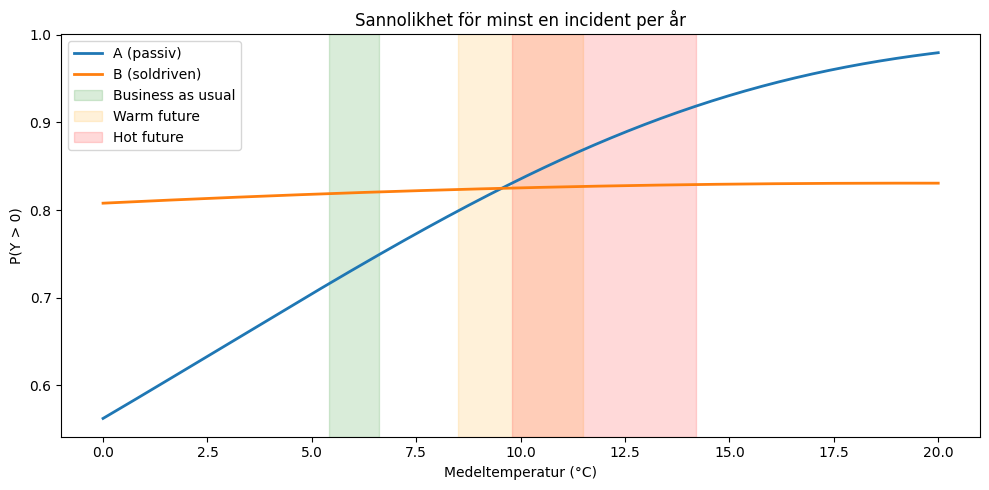

In [328]:
T_grid = np.linspace(0, 20, 200)

fig, ax = plt.subplots(figsize=(10, 5))

# Medelvärde av P(Y>0) över posterior
lam_A_grid = np.exp(b0_A[:, None] + b1_A[:, None] * T_grid[None, :])
lam_B_grid = np.exp(b0_B[:, None] + b1_B[:, None] * T_grid[None, :])
p_A_grid = (1 - np.exp(-lam_A_grid)).mean(axis=0)
p_B_grid = (1 - np.exp(-lam_B_grid)).mean(axis=0)

ax.plot(T_grid, p_A_grid, label="A (passiv)", linewidth=2)
ax.plot(T_grid, p_B_grid, label="B (soldriven)", linewidth=2)

colors = {"Business as usual": "green", "Warm future": "orange", "Hot future": "red"}
for _, row in df_scenario.iterrows():
    ax.axvspan(row["mu"] - row["sigma"], row["mu"] + row["sigma"], 
               alpha=0.15, color=colors[row["scenario"]], label=row["scenario"])

ax.set_xlabel("Medeltemperatur (°C)")
ax.set_ylabel("P(Y > 0)")
ax.set_title("Sannolikhet för minst en incident per år")
ax.legend()
plt.tight_layout()
plt.show()

### Rekommendation till beslutsfattaren

Analysen utvärderar två kylsystem, (A) passiv kylning och (B) soldriven kylning, med avseende på sannolikheten för minst en incident vid ett kärnkraftverk under ett år. Bedömningen görs under tre klimatscenarier som representerar olika möjliga framtida medeltemperaturer: nuvarande klimat (ca 6°C), varmare klimat (ca 10°C) och hett klimat (ca 12°C).

Incidensmodellen för det passiva kylsystemet kalibrerades med observationer från 20 kärnkraftverk världen över, i ett Bayesianskt ramverk som kvantifierar parameterosäkerheten. Modellen för det soldrivna kylsystemet härleddes med hjälp av expertbedömningar av den relativa prestandan mellan systemen vid olika temperaturer. Experternas bedömningar aggregerades och kombinerades med den kalibrerade modellen för att erhålla en fullständig osäkerhetsbeskrivning för båda alternativen.

Klimatscenarierna behandlades som icke-probabilistisk osäkerhet, vilket innebär att de inte tilldelades sannolikheter utan utvärderades separat. Resultaten visar att det passiva kylsystemet ger lägst incidensrisk under nuvarande klimat (P(Y>0) = 0.73 vs 0.82), medan det soldrivna systemet presterar bättre vid varmare (0.83 vs 0.82) och hett klimat (0.87 vs 0.83). Inget alternativ dominerar under samtliga scenarier.

Beslutet beror därmed på beslutsfattarens bedömning av klimatutvecklingen. Om nuvarande klimat bedöms som mest troligt rekommenderas passiv kylning. Om man vill vara robust mot klimatförändringar föredras det soldrivna systemet, som presterar bättre i de två varmare scenarierna och bara marginellt sämre i det nuvarande. En försiktig rekommendation är därför att välja det soldrivna kylsystemet (B), då det ger ett mer klimatrobust skydd.

Osäkerheten i analysen kommer från begränsat antal observerade kärnkraftverk, osäkerhet i experternas bedömningar, samt den fundamentala osäkerheten om framtida klimat.

## Diskussion

**Del 1, uppgift 1–4 (olycksmodellering):** Modellerna kan inte skilja juni från juli eftersom $x_2$ är en gemensam dummyvariabel. Modell 7 fick högst ELPD-vikt (0.66), vilket tyder på att årstrenden ($x_3$) inte tillför mycket. Den modelmedelvägda sannolikheten $P(Y > 2) \approx 15\%$ stämmer med övning 4.

**Del 1, uppgift 5–6 (benchmark-dos):** Den kubiska modellen fick nästan all vikt. Dosvärden transformerades till en gemensam skala för att MCMC-samplern ska konvergera stabilt. BMD beräknades enbart för posterior-dragningar där kurvan faktiskt korsar BMR-nivån, vilket ger en mer försiktig skattning.

**Del 2, uppgift 1 (biasjustering):** En positiv $\beta_s$ bekräftar att studie B överskattar responsen. Genom att sätta studyB = 0 vid BMD-härledningen baseras gränsvärdet på studie A:s nivå.

**Del 2, uppgift 2 (robust beslutsanalys):** Passiv kylning dominerar vid nuvarande klimat medan soldriven kylning är bättre vid varmare scenarier. Klimatscenarierna viktas inte utan utvärderas separat, så beslutsfattaren måste själv bedöma vilka scenarier som är relevanta.

Sammantaget bygger analysen på antaganden om modellstruktur, priorval och hur osäkerhet hanteras. Andra modellval eller beräkningsmetoder kan ge annorlunda resultat, vilket understryker vikten av att kommunicera osäkerhet snarare än enskilda punktskattningar.

## Slutsats

Sannolikheten att fler än två män skadas svårt i trafikolyckor i Blekinge under en sommarmånad 2026 uppskattas till cirka 15%.

HBGV uppskattas till 5.45 i del 1 och 4.88 med studentspecifik biasjusterad data. Båda ligger under medianen av BMD-fördelningen, i linje med LINEX-funktionens asymmetriska bestraffning.

I den robusta analysen rekommenderas det soldrivna kylsystemet, som ger ett mer klimatrobust skydd trots att passiv kylning är bättre under nuvarande förhållanden.

## Generativ AI

Claude har använts för kodgenerering, felsökning och strukturering av rapporten för att effektivisera arbetsprocessen. Alla resultat har verifierats mot kursens övningsmaterial. Analysen, slutsatserna och rekommendationerna är mina egna.